## Simple MultiAI Agent Architecture

In [17]:
import os 
from typing import Annotated, TypedDict, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langgraph.graph import START,StateGraph,END , MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

In [18]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [19]:
## State
class AgentState(MessagesState):
    next_agent:str #Which agent should go next

In [20]:
@tool
def search_web(query:str)-> str:
    """Search the web for information"""
    search = TavilySearchResults(max_results=3)
    results=search.invoke(query)
    return str(results)

@tool
def write_summary(content : str) -> str:
    """Write a summary of the provided content"""
    # Simple Summary generation
    summary  = f"Summary of findings:\n\n{content[:500]}..."
    return summary

In [21]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x0000027FF1D72850>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000027FF1D73250>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [22]:
# Define agent functions 
def researcher_agent(state: AgentState):
    """Researcher agent that searches for the information"""

    messages = state["messages"]

    # Add system message for context
    system_msg = SystemMessage(content="You are a research assistant. Use the search_web tool to find information about the user's request.")

    # Call LLM with tools
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg]+ messages)

    # Return the response and route to writer 
    return {
        "messages":[response],
        "next_agent":"writer"
    }

In [23]:
def writer_agent(state: AgentState):
    """Writer agent that created summaries"""

    messages = state["messages"]

    # Add system message
    system_msg = SystemMessage(content="you are a technical writer. Review the conversion and create clear , concise summary of the findings.")

    response = llm.invoke([system_msg] + messages)

    return {
        "messages":[response],
        "next_agent": "end"
    }

In [24]:
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]

    # Check if there are tool calls to execute 
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        #create tool node and exceute
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response
    
    #No tools to execute 
    return state

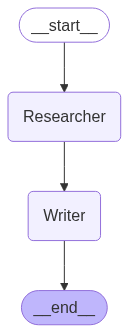

In [27]:
#Build graph

workflow  = StateGraph(MessagesState)

#Add Nodes
workflow.add_node("Researcher", researcher_agent)
workflow.add_node("Writer" , writer_agent)

# Define the flow
workflow.set_entry_point("Researcher")
workflow.add_edge("Researcher", "Writer")
workflow.add_edge("Writer", END)

final_workflow = workflow.compile()

final_workflow


In [31]:
response = final_workflow.invoke({"messages": "Research about the usecase of AgentAI ai in business"})

In [32]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research about the usecase of AgentAI ai in business
================================== Ai Message ==================================
Tool Calls:
  search_web (s304jas4a)
 Call ID: s304jas4a
  Args:
    query: AgentAI ai in business usecase
================================== Ai Message ==================================

"

**Summary of Findings:**

AgentAI is a cutting-edge AI-powered virtual agent designed to enhance customer experience and drive business efficiency. Our research reveals several key use cases for AgentAI in business:

1. **Customer Service**: AgentAI enables businesses to provide 24/7 customer support, improving response times and customer satisfaction. With its advanced conversational AI capabilities, AgentAI can handle complex customer inquiries, reducing the workload of human customer support agents.
2. **Chatbots and Conversational Interfaces**: AgentAI can be integrated with variou